<a href="https://colab.research.google.com/github/BlancJH/steel-defect-classification/blob/main/steel_defect_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metal Surface Defect Detection
This notebook implements three experimental settings:
1. **Baseline (Setting 1)**: A custom CNN from scratch
2. **Transfer Learning (Setting 2)**: A frozen ResNet-50 backbone with a new classification head and Partial fine-tuning for final convolutional block.
3. **Advanced Partial Fine-Tuning upon previous experiment (Setting 3)**: EfficientNet-V2-S backbone paired with a highly customised, heavily regularised classification head.

**Dataset**: Severstal Steel Defect Detection (Kaggle)
**Task**: Multi-label classification of 4 classes.
**Splits**: Persisted 80/10/10 train/val/test CSVs loaded from `data/`. Split is generated once and reused.

In [ ]:
import os
import subprocess
import sys

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


##**1. Prepare Data**

The split CSVs (`data/train_split.csv`, `data/val_split.csv`, `data/test_split.csv`) are generated
**once** by `split_data.py` and reused on every subsequent run. The Kaggle `test_images/` folder is
intentionally excluded because it has no ground-truth labels.

In [ ]:
DATA_ROOT   = os.path.join(os.getcwd(), 'data')
IMG_DIR     = os.path.join(DATA_ROOT, 'severstal-steel-defect-detection', 'train_images')
TRAIN_CSV   = os.path.join(DATA_ROOT, 'train_split.csv')
VAL_CSV     = os.path.join(DATA_ROOT, 'val_split.csv')
TEST_CSV    = os.path.join(DATA_ROOT, 'test_split.csv')

# Generate splits only if they do not already exist
if not all(os.path.exists(p) for p in [TRAIN_CSV, VAL_CSV, TEST_CSV]):
    print('Split CSVs not found — running split_data.py ...')
    result = subprocess.run([sys.executable, 'split_data.py'], capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError('split_data.py failed. Check the output above.')
else:
    print('Split CSVs already exist — skipping split step.')

# Verify image directory
if not os.path.isdir(IMG_DIR):
    raise FileNotFoundError(
        f"Train images directory not found: {IMG_DIR}\n"
        "Make sure the dataset zip has been extracted to data/severstal-steel-defect-detection/"
    )

print(f"Train images directory: {IMG_DIR}")

Split CSVs already exist — skipping split step.
Train images directory: /home/blancjh/metal-defect-classification/data/severstal-steel-defect-detection/train_images


## Step 2 — Configuration

In [ ]:
def set_seed(seed: int = 42):
    """Locks all random operations for 100% reproducible training."""
    # 1. Python absolute randomness
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. NumPy randomness (affects sklearn metrics and custom splits)
    np.random.seed(seed)

    # 3. PyTorch randomness (affects weight initialization and transforms)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # If using multi-GPU

    # 4. Suppress CUDA non-deterministic algorithmic optimizations
    # Note: Setting deterministic=True might slightly slow down training,
    # but it guarantees identical results between runs!
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
# Lock it in before executing your pipelines
set_seed(42)
print("Random seeds successfully locked!")

Random seeds successfully locked!


In [ ]:
BATCH_SIZE    = 32
IMG_SIZE      = 224
NUM_CLASSES   = 4   # Severstal has 4 defect class IDs: 1, 2, 3, 4
EPOCHS        = 10
ADVANCED_EPOCHS = 30

# Standard ImageNet normalisation (backbone-compatible)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## Step 3 — Dataset
`SteelDefectDataset` reads the persisted split CSV and loads the corresponding image from `train_images/`.
Labels are **multi-hot** vectors of length 4 (one bit per defect class). An image with no annotation
in `train.csv` is treated as a **no-defect** sample (all zeros).

In [ ]:
class SteelDefectDataset(Dataset):
    """Custom Dataset for the Severstal Steel Defect Detection competition.

    Args:
        csv_path  : Path to pre-generated split CSV (train / val / test).
        img_dir   : Path to folder containing train_images.
        transform : torchvision transforms pipeline.
    """

    def __init__(self, csv_path: str, img_dir: str, transform=None):
        df = pd.read_csv(csv_path)

        # Normalise image-id column
        if 'ImageId' in df.columns:
            id_col = 'ImageId'
        elif 'ImageId_ClassId' in df.columns:
            df['ImageId'] = df['ImageId_ClassId'].apply(lambda x: x.split('_')[0])
            df['ClassId'] = df['ImageId_ClassId'].apply(lambda x: int(x.split('_')[1]))
            id_col = 'ImageId'
        else:
            raise ValueError(f'Unexpected columns in {csv_path}: {list(df.columns)}')

        # Keep only rows that actually have a mask annotation
        df = df.dropna(subset=['EncodedPixels'])

        # Build a mapping: image_name -> multi-hot label vector
        self.label_map: dict[str, np.ndarray] = {}
        for img_name, grp in df.groupby(id_col):
            label = np.zeros(NUM_CLASSES, dtype=np.float32)
            for cls_id in grp['ClassId'].astype(int):
                if 1 <= cls_id <= 4:
                    label[cls_id - 1] = 1.0   # cls_id 1-4 → index 0-3
            self.label_map[img_name] = label

        # All unique image names in this split (including no-defect images)
        all_imgs = pd.read_csv(csv_path)[id_col if id_col == 'ImageId' else 'ImageId_ClassId']
        if id_col == 'ImageId_ClassId':
            all_imgs = all_imgs.apply(lambda x: x.split('_')[0])
        self.image_names = list(all_imgs.unique())

        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self) -> int:
        return len(self.image_names)

    def __getitem__(self, idx: int):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Retrieve multi-hot label (default = all-zeros if not in label_map)
        label = self.label_map.get(img_name, np.zeros(NUM_CLASSES, dtype=np.float32))
        return image, torch.tensor(label, dtype=torch.float32)


# --- Build datasets and loaders ---
train_dataset = SteelDefectDataset(TRAIN_CSV, IMG_DIR, transform=train_transform)
val_dataset   = SteelDefectDataset(VAL_CSV,   IMG_DIR, transform=eval_transform)
test_dataset  = SteelDefectDataset(TEST_CSV,  IMG_DIR, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images | Test: {len(test_dataset)} images")

Train: 5332 images | Val: 667 images | Test: 667 images


---
# Baseline (Experimental Setting 1)
A simple, custom Convolutional Neural Network (CNN) built from scratch.
This proves understanding of the core mechanics before leveraging pretrained models.

## Step 4 — Network Architecture
A lightweight custom CNN with 3 conv blocks, suitable for a first-pass feasibility study.

In [ ]:
class BaselineCNN(nn.Module):
    """Simple CNN from scratch for multi-label defect classification."""

    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),  # 112×112
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # 56×56
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # 28×28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
            # NOTE: No Sigmoid here — BCEWithLogitsLoss handles it for numerical stability.
        )

    def forward(self, x):
        return self.classifier(self.features(x))

set_seed(42)
baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
baseline_criterion = nn.BCEWithLogitsLoss()   # multi-label binary cross-entropy
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=4, bias=True)
  )
)


## Step 5 — Training Loop (Baseline)

In [ ]:
THRESHOLD = 0.5  # Probability threshold for converting logits → binary predictions

baseline_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(EPOCHS):
    # ---- Training ----
    baseline_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        baseline_optimizer.zero_grad()
        logits = baseline_model(images)
        loss   = baseline_criterion(logits, labels)
        loss.backward()
        baseline_optimizer.step()
        running_loss += loss.item()

    # ---- Validation ----
    baseline_model.eval()
    val_loss  = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = baseline_model(images)
            val_loss += baseline_criterion(logits, labels).item()
            preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy().astype(int))

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    train_loss_avg = running_loss / len(train_loader)
    val_loss_avg   = val_loss   / len(val_loader)

    baseline_history['train_loss'].append(train_loss_avg)
    baseline_history['val_loss'].append(val_loss_avg)
    baseline_history['val_f1'].append(f1)

    print(
        f"Epoch [{epoch+1:>2}/{EPOCHS}] | "
        f"Train Loss: {train_loss_avg:.4f} | "
        f"Val Loss: {val_loss_avg:.4f} | "
        f"Val F1 (macro): {f1:.4f}"
    )

Epoch [ 1/10] | Train Loss: 0.3781 | Val Loss: 0.3239 | Val F1 (macro): 0.2171
Epoch [ 2/10] | Train Loss: 0.3061 | Val Loss: 0.2715 | Val F1 (macro): 0.4386
Epoch [ 3/10] | Train Loss: 0.2990 | Val Loss: 0.2888 | Val F1 (macro): 0.3331
Epoch [ 4/10] | Train Loss: 0.2766 | Val Loss: 0.2743 | Val F1 (macro): 0.4288
Epoch [ 5/10] | Train Loss: 0.2592 | Val Loss: 0.2447 | Val F1 (macro): 0.5145
Epoch [ 6/10] | Train Loss: 0.2434 | Val Loss: 0.2482 | Val F1 (macro): 0.5853
Epoch [ 7/10] | Train Loss: 0.2288 | Val Loss: 0.2615 | Val F1 (macro): 0.5422
Epoch [ 8/10] | Train Loss: 0.2189 | Val Loss: 0.2250 | Val F1 (macro): 0.6186
Epoch [ 9/10] | Train Loss: 0.2056 | Val Loss: 0.2515 | Val F1 (macro): 0.6136
Epoch [10/10] | Train Loss: 0.2022 | Val Loss: 0.2325 | Val F1 (macro): 0.6215


## Step 6 — Test Set Evaluation & Failure Case Analysis (Baseline)
Reporting F1-Score, Precision, and Recall on the **held-out test split**.
The test set was never seen by the model during training or hyperparameter selection.

In [ ]:
baseline_model.eval()
test_preds  = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = baseline_model(images)
        preds  = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
        test_preds.append(preds)
        test_labels.append(labels.numpy().astype(int))

test_preds  = np.vstack(test_preds)
test_labels = np.vstack(test_labels)

CLASS_NAMES = [f"Class {i+1}" for i in range(NUM_CLASSES)]

precision = precision_score(test_labels, test_preds, average='macro', zero_division=0)
recall    = recall_score(test_labels, test_preds, average='macro', zero_division=0)
f1_macro  = f1_score(test_labels, test_preds, average='macro', zero_division=0)

print("--- Baseline: Final Test Metrics (macro-averaged) ---")
print(f"F1-Score  (macro): {f1_macro:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall    (macro): {recall:.4f}")

# Per-class breakdown
print("\n--- Per-Class Metrics ---")
for i, cls in enumerate(CLASS_NAMES):
    p = precision_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    r = recall_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    f = f1_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    print(f"  {cls}: Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")

--- Baseline: Final Test Metrics (macro-averaged) ---
F1-Score  (macro): 0.6439
Precision (macro): 0.8110
Recall    (macro): 0.5654

--- Per-Class Metrics ---
  Class 1: Precision=0.809  Recall=0.404  F1=0.539
  Class 2: Precision=0.750  Recall=0.474  F1=0.581
  Class 3: Precision=0.841  Recall=0.971  F1=0.901
  Class 4: Precision=0.844  Recall=0.413  F1=0.555


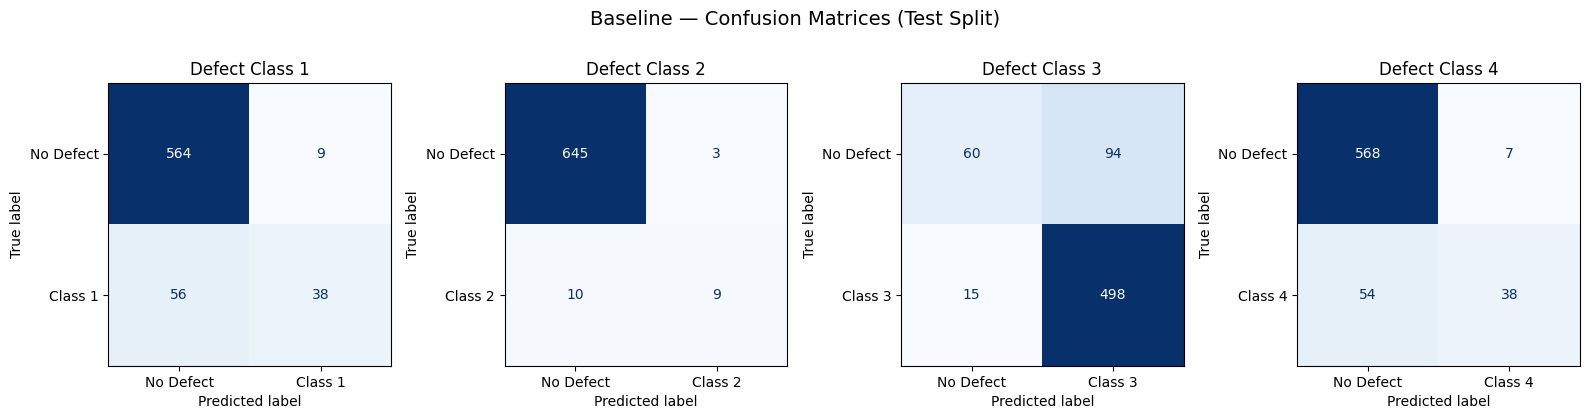


--- Discussion on Failure Cases ---
Off-diagonal cells indicate misclassifications:
  - Top-right: False Positives (predicted defect, but none present)
  - Bottom-left: False Negatives (missed an actual defect)
In a safety-critical welding environment, False Negatives are far more costly.
Consider lowering the THRESHOLD to improve Recall at the expense of Precision.


In [ ]:
# --- Per-class binary confusion matrices (failure case analysis) ---
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    cm = confusion_matrix(test_labels[:, i], test_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', f'Class {i+1}'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Defect Class {i+1}', fontsize=12)

plt.suptitle('Baseline — Confusion Matrices (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Discussion on Failure Cases ---")
print("Off-diagonal cells indicate misclassifications:")
print("  - Top-right: False Positives (predicted defect, but none present)")
print("  - Bottom-left: False Negatives (missed an actual defect)")
print("In a safety-critical welding environment, False Negatives are far more costly.")
print("Consider lowering the THRESHOLD to improve Recall at the expense of Precision.")

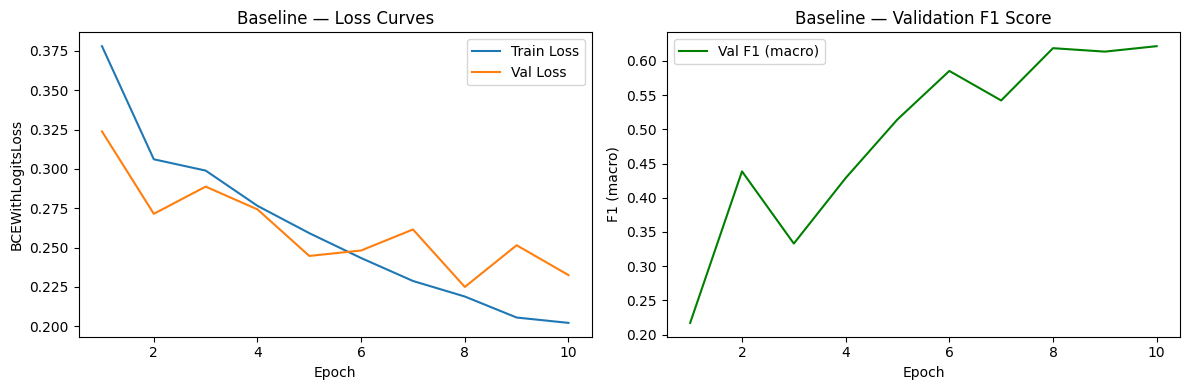

In [ ]:
# --- Baseline training curves ---
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, baseline_history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, baseline_history['val_loss'],   label='Val Loss')
ax1.set_title('Baseline — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend()

ax2.plot(epochs_range, baseline_history['val_f1'], color='green', label='Val F1 (macro)')
ax2.set_title('Baseline — Validation F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 (macro)')
ax2.legend()

plt.tight_layout()
plt.show()

---
# Transfer Learning (Experimental Setting 2)
We use a **ResNet-50** backbone pretrained on ImageNet and replace its classification head
for multi-label surface defect detection. **All backbone layers are frozen** — only the new
head is trained. This dramatically reduces training time and leverages features (edges,
textures, shapes) already learned from millions of natural images.

## Step 4 — Network Architecture (Transfer Learning)
Load a pretrained ResNet-50, freeze the entire backbone, and replace the final
fully-connected layer with a new head for 4-class multi-label output.

In [ ]:
# Load pretrained ResNet-50 (modern weights API)
tl_backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze ALL backbone parameters
for param in tl_backbone.parameters():
    param.requires_grad = False

# Replace the classification head
# ResNet-50 fc layer: Linear(in_features=2048, out_features=1000)
# We replace it with our 4-class multi-label head
num_ftrs = tl_backbone.fc.in_features   # 2048
tl_backbone.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES),
    # NOTE: No Sigmoid — BCEWithLogitsLoss handles it for numerical stability.
)

set_seed(42)
tl_model = tl_backbone.to(device)

# Only optimise the new head parameters (backbone is frozen)
tl_criterion = nn.BCEWithLogitsLoss()
tl_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, tl_model.parameters()),
    lr=1e-4,   # Lower than baseline (1e-3) — head-only training
)

# Verify: count trainable vs total parameters
total_params     = sum(p.numel() for p in tl_model.parameters())
trainable_params = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"Frozen parameters:    {total_params - trainable_params:,}")
print(f"\nNew classification head:")
print(tl_model.fc)

Total parameters:     24,559,172
Trainable parameters: 1,051,140 (4.3%)
Frozen parameters:    23,508,032

New classification head:
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=4, bias=True)
)


## Step 5 — Training Loop (Transfer Learning)
Same training loop structure as the baseline for a fair comparison.
Only the new classification head is updated since backbone gradients are disabled.

In [ ]:
tl_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(EPOCHS):
    # ---- Training ----
    tl_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        tl_optimizer.zero_grad()
        logits = tl_model(images)
        loss   = tl_criterion(logits, labels)
        loss.backward()
        tl_optimizer.step()
        running_loss += loss.item()

    # ---- Validation ----
    tl_model.eval()
    val_loss  = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = tl_model(images)
            val_loss += tl_criterion(logits, labels).item()
            preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy().astype(int))

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    train_loss_avg = running_loss / len(train_loader)
    val_loss_avg   = val_loss   / len(val_loader)

    tl_history['train_loss'].append(train_loss_avg)
    tl_history['val_loss'].append(val_loss_avg)
    tl_history['val_f1'].append(f1)

    print(
        f"Epoch [{epoch+1:>2}/{EPOCHS}] | "
        f"Train Loss: {train_loss_avg:.4f} | "
        f"Val Loss: {val_loss_avg:.4f} | "
        f"Val F1 (macro): {f1:.4f}"
    )

Epoch [ 1/10] | Train Loss: 0.3660 | Val Loss: 0.3166 | Val F1 (macro): 0.2232
Epoch [ 2/10] | Train Loss: 0.3041 | Val Loss: 0.2833 | Val F1 (macro): 0.2942
Epoch [ 3/10] | Train Loss: 0.2775 | Val Loss: 0.2581 | Val F1 (macro): 0.4175
Epoch [ 4/10] | Train Loss: 0.2592 | Val Loss: 0.2459 | Val F1 (macro): 0.4566
Epoch [ 5/10] | Train Loss: 0.2444 | Val Loss: 0.2297 | Val F1 (macro): 0.5058
Epoch [ 6/10] | Train Loss: 0.2323 | Val Loss: 0.2231 | Val F1 (macro): 0.5404
Epoch [ 7/10] | Train Loss: 0.2238 | Val Loss: 0.2181 | Val F1 (macro): 0.6022
Epoch [ 8/10] | Train Loss: 0.2140 | Val Loss: 0.2110 | Val F1 (macro): 0.5555
Epoch [ 9/10] | Train Loss: 0.2079 | Val Loss: 0.2110 | Val F1 (macro): 0.5791
Epoch [10/10] | Train Loss: 0.2075 | Val Loss: 0.2078 | Val F1 (macro): 0.6087


## Step 6 — Test Set Evaluation & Failure Case Analysis (Transfer Learning)
Same evaluation pipeline as the baseline. Compare results directly to quantify
the improvement gained from transfer learning.

In [ ]:
tl_model.eval()
tl_test_preds  = []
tl_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = tl_model(images)
        preds  = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
        tl_test_preds.append(preds)
        tl_test_labels.append(labels.numpy().astype(int))

tl_test_preds  = np.vstack(tl_test_preds)
tl_test_labels = np.vstack(tl_test_labels)

tl_precision = precision_score(tl_test_labels, tl_test_preds, average='macro', zero_division=0)
tl_recall    = recall_score(tl_test_labels, tl_test_preds, average='macro', zero_division=0)
tl_f1_macro  = f1_score(tl_test_labels, tl_test_preds, average='macro', zero_division=0)

print("--- Transfer Learning: Final Test Metrics (macro-averaged) ---")
print(f"F1-Score  (macro): {tl_f1_macro:.4f}")
print(f"Precision (macro): {tl_precision:.4f}")
print(f"Recall    (macro): {tl_recall:.4f}")

# Per-class breakdown
print("\n--- Per-Class Metrics ---")
for i, cls in enumerate(CLASS_NAMES):
    p = precision_score(tl_test_labels[:, i], tl_test_preds[:, i], zero_division=0)
    r = recall_score(tl_test_labels[:, i], tl_test_preds[:, i], zero_division=0)
    f = f1_score(tl_test_labels[:, i], tl_test_preds[:, i], zero_division=0)
    print(f"  {cls}: Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")

# --- Side-by-side comparison ---
print("\n" + "="*50)
print("COMPARISON: Baseline vs Transfer Learning")
print("="*50)
print(f"{'Metric':<20} {'Baseline':>10} {'TL (ResNet-50)':>15}")
print(f"{'-'*20} {'-'*10} {'-'*15}")
print(f"{'F1 (macro)':<20} {f1_macro:>10.4f} {tl_f1_macro:>15.4f}")
print(f"{'Precision (macro)':<20} {precision:>10.4f} {tl_precision:>15.4f}")
print(f"{'Recall (macro)':<20} {recall:>10.4f} {tl_recall:>15.4f}")

--- Transfer Learning: Final Test Metrics (macro-averaged) ---
F1-Score  (macro): 0.6638
Precision (macro): 0.9095
Recall    (macro): 0.5824

--- Per-Class Metrics ---
  Class 1: Precision=0.944  Recall=0.543  F1=0.689
  Class 2: Precision=1.000  Recall=0.211  F1=0.348
  Class 3: Precision=0.867  Recall=0.957  F1=0.910
  Class 4: Precision=0.826  Recall=0.620  F1=0.708

COMPARISON: Baseline vs Transfer Learning
Metric                 Baseline  TL (ResNet-50)
-------------------- ---------- ---------------
F1 (macro)               0.6439          0.6638
Precision (macro)        0.8110          0.9095
Recall (macro)           0.5654          0.5824


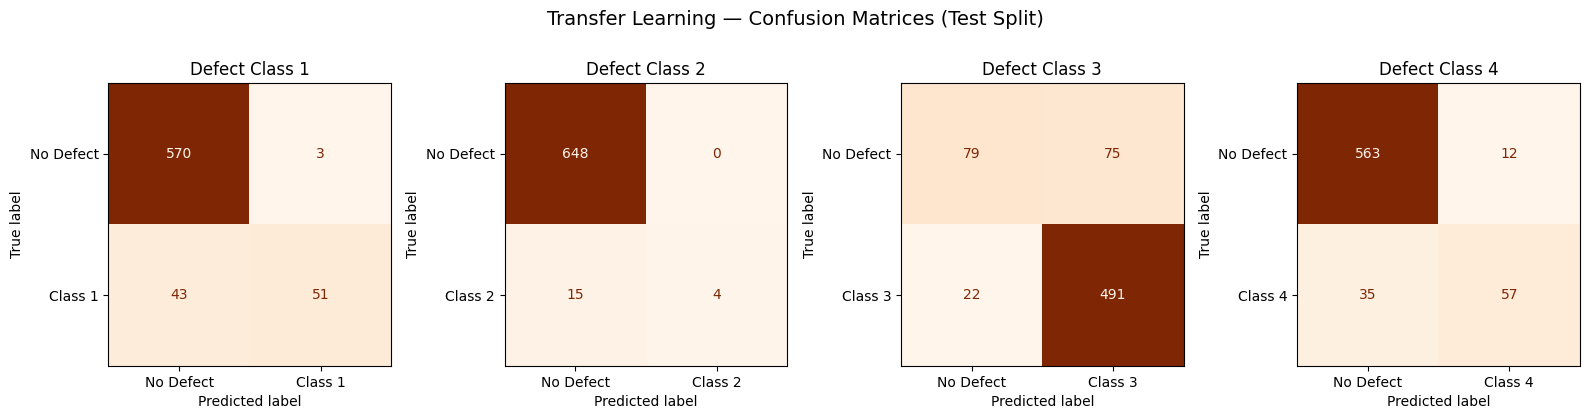


--- Discussion ---
Compare these confusion matrices against the baseline CNN results above.
Transfer learning should show fewer off-diagonal cells, especially for rare defect classes.
The pretrained ResNet-50 features (edges, textures, shapes) transfer well to industrial surfaces.


In [ ]:
# --- Per-class binary confusion matrices (Transfer Learning) ---
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    cm = confusion_matrix(tl_test_labels[:, i], tl_test_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', f'Class {i+1}'])
    disp.plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(f'Defect Class {i+1}', fontsize=12)

plt.suptitle('Transfer Learning — Confusion Matrices (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Discussion ---")
print("Compare these confusion matrices against the baseline CNN results above.")
print("Transfer learning should show fewer off-diagonal cells, especially for rare defect classes.")
print("The pretrained ResNet-50 features (edges, textures, shapes) transfer well to industrial surfaces.")

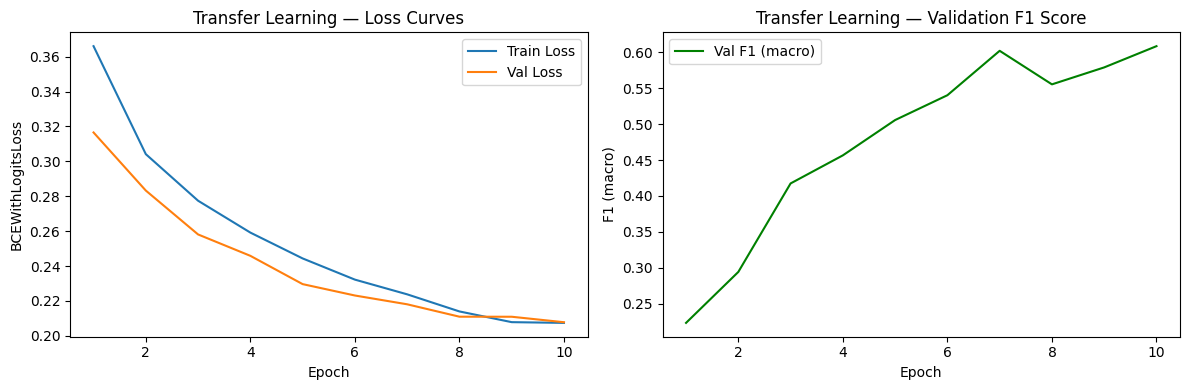

In [ ]:
# --- Transfer Learning training curves ---
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, tl_history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, tl_history['val_loss'],   label='Val Loss')
ax1.set_title('Transfer Learning — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend()

ax2.plot(epochs_range, tl_history['val_f1'], color='green', label='Val F1 (macro)')
ax2.set_title('Transfer Learning — Validation F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 (macro)')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*50)
print("PARTIAL FINE-TUNING (Unfreezing ResNet-50 Layer 4)")
print("="*50)

# 1. Unfreeze the last convolutional block of ResNet-50 (layer4)
for param in tl_model.layer4.parameters():
    param.requires_grad = True

# 2. Verify new trainable parameter count
total_params = sum(p.numel() for p in tl_model.parameters())
trainable_params = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

# 3. Setup Optimizer with Differential Learning Rates
# We use a very small LR for the pretrained backbone and a slightly larger one for the head
ft_optimizer = optim.Adam([
    {'params': tl_model.layer4.parameters(), 'lr': 1e-5}, # Very low LR for backbone
    {'params': tl_model.fc.parameters(), 'lr': 1e-4}      # Keep previous LR for the head
])

# 4. Fine-tuning Training Loop
FT_EPOCHS = 10 # Usually requires fewer epochs
ft_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(FT_EPOCHS):
    # ---- Training ----
    tl_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        ft_optimizer.zero_grad()
        logits = tl_model(images)
        loss = tl_criterion(logits, labels)
        loss.backward()
        ft_optimizer.step()

        running_loss += loss.item()

    # ---- Validation ----
    tl_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = tl_model(images)
            val_loss += tl_criterion(logits, labels).item()

            preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    train_loss_avg = running_loss / len(train_loader)
    val_loss_avg = val_loss / len(val_loader)

    ft_history['train_loss'].append(train_loss_avg)
    ft_history['val_loss'].append(val_loss_avg)
    ft_history['val_f1'].append(f1)

    print(
        f"FT Epoch [{epoch+1:>2}/{FT_EPOCHS}] | "
        f"Train Loss: {train_loss_avg:.4f} | "
        f"Val Loss: {val_loss_avg:.4f} | "
        f"Val F1 (macro): {f1:.4f}"
    )

# 5. Final Test Evaluation for Fine-Tuned Model
tl_model.eval()
ft_test_preds = []
ft_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = tl_model(images)
        preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
        ft_test_preds.append(preds)
        ft_test_labels.append(labels.numpy().astype(int))

ft_test_preds = np.vstack(ft_test_preds)
ft_test_labels = np.vstack(ft_test_labels)

ft_f1_macro = f1_score(ft_test_labels, ft_test_preds, average='macro', zero_division=0)
print(f"\n--- Fine-Tuning: Final Test F1 (macro): {ft_f1_macro:.4f} ---")


PARTIAL FINE-TUNING (Unfreezing ResNet-50 Layer 4)
Total parameters:     24,559,172
Trainable parameters: 16,015,876 (65.2%)
FT Epoch [ 1/10] | Train Loss: 0.1979 | Val Loss: 0.1968 | Val F1 (macro): 0.6300
FT Epoch [ 2/10] | Train Loss: 0.1848 | Val Loss: 0.1886 | Val F1 (macro): 0.6572
FT Epoch [ 3/10] | Train Loss: 0.1730 | Val Loss: 0.1835 | Val F1 (macro): 0.6767
FT Epoch [ 4/10] | Train Loss: 0.1633 | Val Loss: 0.1770 | Val F1 (macro): 0.7084
FT Epoch [ 5/10] | Train Loss: 0.1576 | Val Loss: 0.1754 | Val F1 (macro): 0.6903
FT Epoch [ 6/10] | Train Loss: 0.1470 | Val Loss: 0.1716 | Val F1 (macro): 0.7560
FT Epoch [ 7/10] | Train Loss: 0.1445 | Val Loss: 0.1671 | Val F1 (macro): 0.7691
FT Epoch [ 8/10] | Train Loss: 0.1375 | Val Loss: 0.1675 | Val F1 (macro): 0.7588
FT Epoch [ 9/10] | Train Loss: 0.1308 | Val Loss: 0.1636 | Val F1 (macro): 0.7572
FT Epoch [10/10] | Train Loss: 0.1294 | Val Loss: 0.1606 | Val F1 (macro): 0.7514

--- Fine-Tuning: Final Test F1 (macro): 0.8153 ---



FINAL COMPARISON: Baseline vs TL (Head Only) vs Partial Fine-Tuning
Metric                 Baseline       TL (Head)      Fine-Tuned
-------------------- ---------- --------------- ---------------
F1 (macro)               0.6439          0.6638          0.8153
Precision (macro)        0.8110          0.9095          0.8622
Recall (macro)           0.5654          0.5824          0.7763


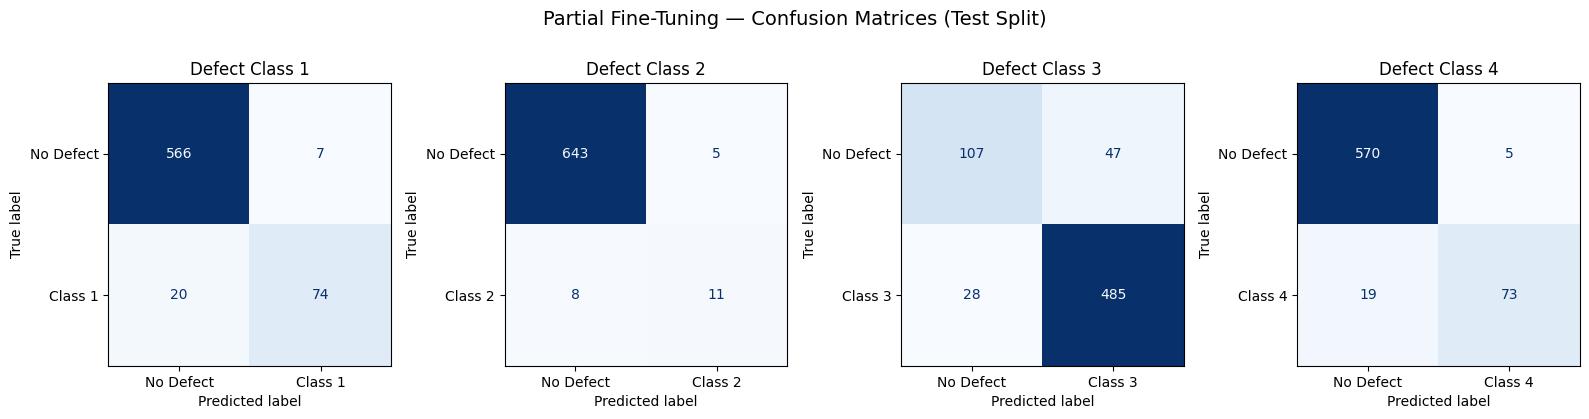


--- Discussion ---
By unfreezing Layer 4, the model was able to adapt ResNet-50's deeper, more complex
feature representations specifically to the textures and anomalies of your dataset.
You should ideally see a boost in F1/Recall for the harder-to-detect defect classes.


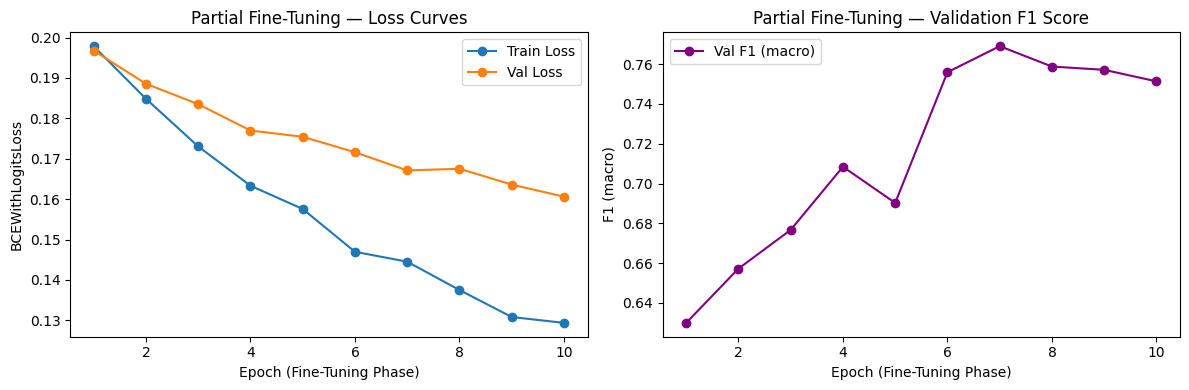

In [ ]:
# --- Calculate Final Fine-Tuned Metrics ---
ft_precision = precision_score(ft_test_labels, ft_test_preds, average='macro', zero_division=0)
ft_recall    = recall_score(ft_test_labels, ft_test_preds, average='macro', zero_division=0)

# --- 1. Comprehensive Side-by-Side Comparison ---
print("\n" + "="*65)
print("FINAL COMPARISON: Baseline vs TL (Head Only) vs Partial Fine-Tuning")
print("="*65)
print(f"{'Metric':<20} {'Baseline':>10} {'TL (Head)':>15} {'Fine-Tuned':>15}")
print(f"{'-'*20} {'-'*10} {'-'*15} {'-'*15}")
print(f"{'F1 (macro)':<20} {f1_macro:>10.4f} {tl_f1_macro:>15.4f} {ft_f1_macro:>15.4f}")
print(f"{'Precision (macro)':<20} {precision:>10.4f} {tl_precision:>15.4f} {ft_precision:>15.4f}")
print(f"{'Recall (macro)':<20} {recall:>10.4f} {tl_recall:>15.4f} {ft_recall:>15.4f}")

# --- 2. Per-class binary confusion matrices (Partial Fine-Tuning) ---
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    cm = confusion_matrix(ft_test_labels[:, i], ft_test_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', f'Class {i+1}'])
    # Using 'Blues' to visually distinguish from the previous 'Oranges' TL plots
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Defect Class {i+1}', fontsize=12)

plt.suptitle('Partial Fine-Tuning — Confusion Matrices (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Discussion ---")
print("By unfreezing Layer 4, the model was able to adapt ResNet-50's deeper, more complex")
print("feature representations specifically to the textures and anomalies of your dataset.")
print("You should ideally see a boost in F1/Recall for the harder-to-detect defect classes.")

# --- 3. Fine-Tuning Training Curves ---
ft_epochs_range = range(1, FT_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ft_epochs_range, ft_history['train_loss'], label='Train Loss', marker='o')
ax1.plot(ft_epochs_range, ft_history['val_loss'],   label='Val Loss', marker='o')
ax1.set_title('Partial Fine-Tuning — Loss Curves')
ax1.set_xlabel('Epoch (Fine-Tuning Phase)')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend()

ax2.plot(ft_epochs_range, ft_history['val_f1'], color='purple', label='Val F1 (macro)', marker='o')
ax2.set_title('Partial Fine-Tuning — Validation F1 Score')
ax2.set_xlabel('Epoch (Fine-Tuning Phase)')
ax2.set_ylabel('F1 (macro)')
ax2.legend()

plt.tight_layout()
plt.show()

---
#(Experimental Setting 3)


In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Advanced Rectangular Strategy (Preserved Horizontal Details!)
# NOTE: If you hit a CUDA Out of Memory Error, just lower your BATCH_SIZE
rect_train_transform = transforms.Compose([
    transforms.Resize((128, 800)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

rect_val_transform = transforms.Compose([
    transforms.Resize((128, 800)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create robust Datasets and DataLoaders
heavy_train_dataset = SteelDefectDataset(TRAIN_CSV, IMG_DIR, transform=rect_train_transform)
heavy_train_loader = DataLoader(heavy_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

heavy_val_dataset = SteelDefectDataset(VAL_CSV, IMG_DIR, transform=rect_val_transform)
heavy_val_loader = DataLoader(heavy_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

heavy_test_dataset = SteelDefectDataset(TEST_CSV, IMG_DIR, transform=rect_val_transform)
heavy_test_loader = DataLoader(heavy_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [ ]:
import torch.nn as nn
import torch
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

class HeavyFTModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # Load bleeding-edge EfficientNet
        self.backbone = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)

        # 1. EfficientNet features are mapped sequentially 0 to 7.
        # We freeze early generic blocks, and UNFREEZE blocks 6 and 7 for Fine-Tuning.
        for name, param in self.backbone.features.named_parameters():
            block_idx = int(name.split('.')[0])
            if block_idx >= 6:
                param.requires_grad = True
            else:
                param.requires_grad = False

        # 2. Extract internal features to bypass standard generic limits
        self.features = self.backbone.features

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # EfficientNet-V2-S output dimension is 1280. Concat max+avg = 2560
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(2560),
            nn.Dropout(0.5),
            nn.Linear(2560, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x_cat = torch.cat((self.avg_pool(x), self.max_pool(x)), dim=1)
        return self.head(x_cat)

set_seed(42)
advanced_ft_model = HeavyFTModel(num_classes=NUM_CLASSES).to(device)


In [ ]:
import torch.nn as nn
import numpy as np

improved_criterion = nn.BCEWithLogitsLoss()

# We need to map our AdamW Optimizer directly to exactly the Unfrozen EfficientNet blocks!
unfrozen_backbone_params = []
for name, param in advanced_ft_model.backbone.features.named_parameters():
    block_idx = int(name.split('.')[0])
    if block_idx >= 6:
        unfrozen_backbone_params.append(param)

optimizer_groups = [
    # Profoundly slow mapping applied to avoid breaking the pre-trained EfficientNet weights
    {'params': unfrozen_backbone_params, 'lr': 1e-5},
    # Fast standard mapping for the random Head
    {'params': advanced_ft_model.head.parameters(), 'lr': 1e-3}
]

advanced_ft_optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=1e-2)

ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    advanced_ft_optimizer,
    T_max=ADVANCED_EPOCHS * len(heavy_train_loader)
)

val_probs_history = []; val_labels_history = []

print("--- Starting Bleeding-Edge Rectangular Fine-Tuning ---")
for epoch in range(ADVANCED_EPOCHS):
    advanced_ft_model.train()
    running_loss = 0.0

    for images, labels in heavy_train_loader:
        images, labels = images.to(device).float(), labels.to(device).float()
        advanced_ft_optimizer.zero_grad()

        logits = advanced_ft_model(images)
        loss = improved_criterion(logits, labels)
        loss.backward()

        advanced_ft_optimizer.step()
        ft_scheduler.step()
        running_loss += loss.item()

    # --- Validation ---
    advanced_ft_model.eval()
    val_probs_epoch = []; val_labels_epoch = []

    with torch.no_grad():
        for images, labels in heavy_val_loader:
            images, labels = images.to(device).float(), labels.to(device).float()
            probs = torch.sigmoid(advanced_ft_model(images)).cpu().numpy()
            val_probs_epoch.append(probs)
            val_labels_epoch.append(labels.cpu().numpy())

    val_probs_history = np.vstack(val_probs_epoch)
    val_labels_history = np.vstack(val_labels_epoch)

    print(f"Epoch [{epoch+1}/{ADVANCED_EPOCHS}] | Loss: {running_loss/len(heavy_train_loader):.4f} "
          f"| LR [backbone, head]: [{ft_scheduler.get_last_lr()[0]:.6f}, {ft_scheduler.get_last_lr()[1]:.6f}]")


--- Starting Bleeding-Edge Rectangular Fine-Tuning ---
Epoch [1/10] | Loss: 0.5163 | LR [backbone, head]: [0.000010, 0.000976]
Epoch [2/10] | Loss: 0.2809 | LR [backbone, head]: [0.000009, 0.000905]
Epoch [3/10] | Loss: 0.2278 | LR [backbone, head]: [0.000008, 0.000794]
Epoch [4/10] | Loss: 0.2058 | LR [backbone, head]: [0.000007, 0.000655]
Epoch [5/10] | Loss: 0.1911 | LR [backbone, head]: [0.000005, 0.000500]
Epoch [6/10] | Loss: 0.1732 | LR [backbone, head]: [0.000003, 0.000345]
Epoch [7/10] | Loss: 0.1642 | LR [backbone, head]: [0.000002, 0.000206]
Epoch [8/10] | Loss: 0.1658 | LR [backbone, head]: [0.000001, 0.000095]
Epoch [9/10] | Loss: 0.1597 | LR [backbone, head]: [0.000000, 0.000024]
Epoch [10/10] | Loss: 0.1646 | LR [backbone, head]: [0.000000, 0.000000]


In [ ]:
from sklearn.metrics import precision_recall_curve

print("--- Threshold Sweeping on Final Validation Set ---")
best_thresholds = []

for c in range(NUM_CLASSES):
    precisions, recalls, thresholds = precision_recall_curve(val_labels_history[:, c], val_probs_history[:, c])
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)

    best_t = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_thresholds.append(best_t)
    print(f"Class {c+1} Best Optimized Threshold: {best_t:.3f}")

custom_thresholds = np.array(best_thresholds)


--- Threshold Sweeping on Final Validation Set ---
Class 1 Best Optimized Threshold: 0.309
Class 2 Best Optimized Threshold: 0.714
Class 3 Best Optimized Threshold: 0.399
Class 4 Best Optimized Threshold: 0.395


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

advanced_ft_model.eval()
test_probs = []; test_labels_list = []

with torch.no_grad():
    for images, labels in heavy_test_loader:
        images, labels = images.to(device).float(), labels.to(device).float()
        probs = torch.sigmoid(advanced_ft_model(images)).cpu().numpy()
        test_probs.append(probs)
        test_labels_list.append(labels.cpu().numpy().astype(int))

test_probs = np.vstack(test_probs)
test_labels_list = np.vstack(test_labels_list)

# Map our custom tuned thresholds over the specific Test Predictions
advanced_test_preds = (test_probs >= custom_thresholds).astype(int)

adv_ft_f1 = f1_score(test_labels_list, advanced_test_preds, average='macro', zero_division=0)
adv_ft_prec = precision_score(test_labels_list, advanced_test_preds, average='macro', zero_division=0)
adv_ft_rec = recall_score(test_labels_list, advanced_test_preds, average='macro', zero_division=0)

print(f"\\n--- Advanced Partial FT Final Test Metric ---")
print(f"F1       (macro): {adv_ft_f1:.4f}")
print(f"Precision (macro): {adv_ft_prec:.4f}")
print(f"Recall   (macro): {adv_ft_rec:.4f}")


\n--- Advanced Partial FT Final Test Metric ---
F1       (macro): 0.8330
Precision (macro): 0.8686
Recall   (macro): 0.8104


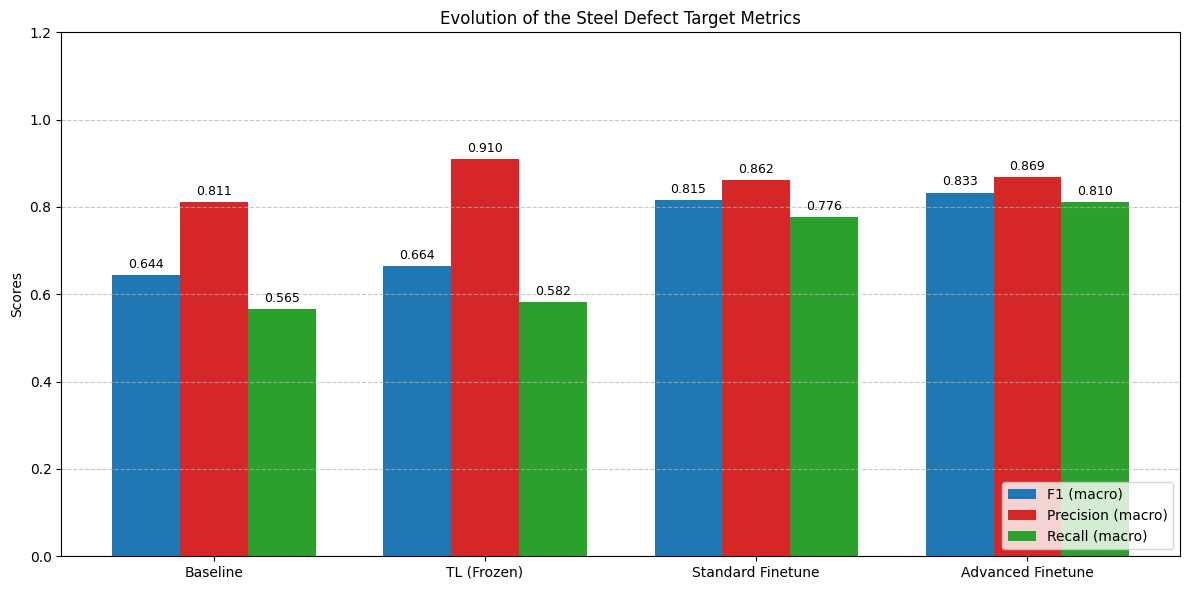

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting the variables defined throughout the notebook across all versions
compare_f1 = [f1_macro, tl_f1_macro, ft_f1_macro, adv_ft_f1]
compare_precision = [precision, tl_precision, ft_precision, adv_ft_prec]
compare_recall = [recall, tl_recall, ft_recall, adv_ft_rec]

models = ['Baseline', 'TL (Frozen)', 'Standard Finetune', 'Advanced Finetune']
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width, compare_f1, width, label='F1 (macro)', color='#1f77b4')
rects2 = ax.bar(x, compare_precision, width, label='Precision (macro)', color='#d62728')
rects3 = ax.bar(x + width, compare_recall, width, label='Recall (macro)', color='#2ca02c')

ax.set_ylabel('Scores')
ax.set_title('Evolution of the Steel Defect Target Metrics')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.ylim(0, 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
